# Amortized course-prior prototype — Phase 1a (closed-form Gaussian toy)

This notebook is the Phase 1a deliverable for the amortized course-prior
prototype (see `notes/coursepriorterm_audit.md` for orientation).
It demonstrates that the amortized network plumbing (`python/pybrimstone/amortized/`)
learns the closed-form Gaussian toy and comes in close to the linear-regression
baseline. It does **not** speak to real-data amortization quality — see
`notes/coursepriorterm_audit.md` and Phase 1b for that.

## What the toy is

Per sample, draw a random PSD matrix `A`, a Gaussian `b`, a course-prior mean `mu`,
and a positive precision `lam`. The closed-form 'phase-optimal' solution is

```
x_star = (A + diag(lam))^-1 (b + lam * mu)
```

The amortized network sees `(x_init, mu, lam)` and is asked to predict
`delta_x = x_star - x_init`. The latent `(A, b)` are **not** in the input,
so an irreducible error floor exists — we are not aiming for zero MSE.

## Disclaimer

Everything below is amortized-path output on a synthetic toy. Do not use these
metrics as a stand-in for radiotherapy planning behavior.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make pybrimstone importable from the repo root regardless of where the
# notebook is launched from.
repo_python = Path('..').resolve() / 'python'
if str(repo_python) not in sys.path:
    sys.path.insert(0, str(repo_python))

from pybrimstone.amortized import PrototypeConfig
from pybrimstone.amortized.data import generate_toy_samples
from pybrimstone.amortized.train import train

/home/user/dH/python/pybrimstone/__init__.py:38: UserWarning: Cython extensions not built. Please run 'pip install -e .' to build. Error: No module named 'pybrimstone.core'
  warnings.warn(


## 1. Generate the toy corpus

10k samples, `phase_dim=16` (small enough that the notebook runs in a minute).
Larger dims would test the architecture more but Phase 1a is about plumbing.

In [2]:
PHASE_DIM = 16
COURSE_DIM = 2 * PHASE_DIM

rng = np.random.default_rng(0)
samples = generate_toy_samples(n_samples=10_000, phase_dim=PHASE_DIM, rng=rng)

delta_stack = np.stack([s.delta_x for s in samples])
x_stack = np.stack([s.x_init for s in samples])
x_star_stack = x_stack + delta_stack
print(f'corpus: {len(samples)} samples, phase_dim={PHASE_DIM}')
print(f'  var(delta_x): {delta_stack.var():.3f}')
print(f'  var(x_init):  {x_stack.var():.3f}')
print(f'  var(x_star):  {x_star_stack.var():.3f}')

corpus: 10000 samples, phase_dim=16
  var(delta_x): 1.343
  var(x_init):  0.996
  var(x_star):  0.347


## 2. Train

In [3]:
cfg = PrototypeConfig(
    phase_dim=PHASE_DIM,
    course_dim=COURSE_DIM,
    hidden=64,
    epochs=80,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-3,
    val_fraction=0.1,
    seed=13,
)
result = train(samples, cfg)
print(f'best val MSE:      {result.best_val_mse:.4f}')
print(f'zero baseline:     {result.baseline_zero_val_mse:.4f}')
print(f'linear baseline:   {result.baseline_linear_val_mse:.4f}')
print(f'ratio MLP / LR:    {result.best_val_mse / result.baseline_linear_val_mse:.3f}')

best val MSE:      0.3122
zero baseline:     1.3489
linear baseline:   0.3049
ratio MLP / LR:    1.024


## 3. Training curve

Train and val MSE per epoch, with both baselines drawn for reference.
Plot title carries the **AMORTIZED** label to keep the disclaimer
visually attached to any saved screenshot.

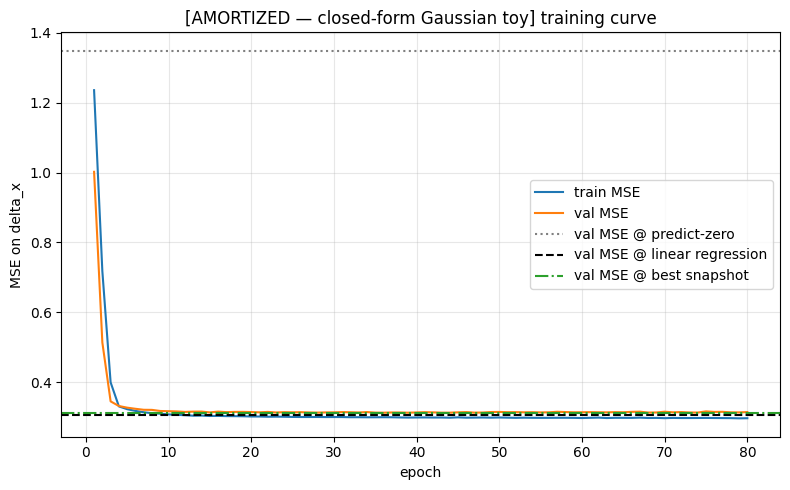

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs = np.arange(1, len(result.train_loss) + 1)
ax.plot(epochs, result.train_loss, label='train MSE')
ax.plot(epochs, result.val_loss, label='val MSE')
ax.axhline(result.baseline_zero_val_mse,
           color='gray', linestyle=':', label='val MSE @ predict-zero')
ax.axhline(result.baseline_linear_val_mse,
           color='black', linestyle='--', label='val MSE @ linear regression')
ax.axhline(result.best_val_mse,
           color='C2', linestyle='-.', label='val MSE @ best snapshot')
ax.set_xlabel('epoch')
ax.set_ylabel('MSE on delta_x')
ax.set_title('[AMORTIZED — closed-form Gaussian toy] training curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Held-out parity plot

Scatter of predicted vs true `delta_x` on the val split, all components flattened.
Diagonal = perfect prediction. Spread off the diagonal is the irreducible error
from the latent `(A, b)` not being in the network's input.

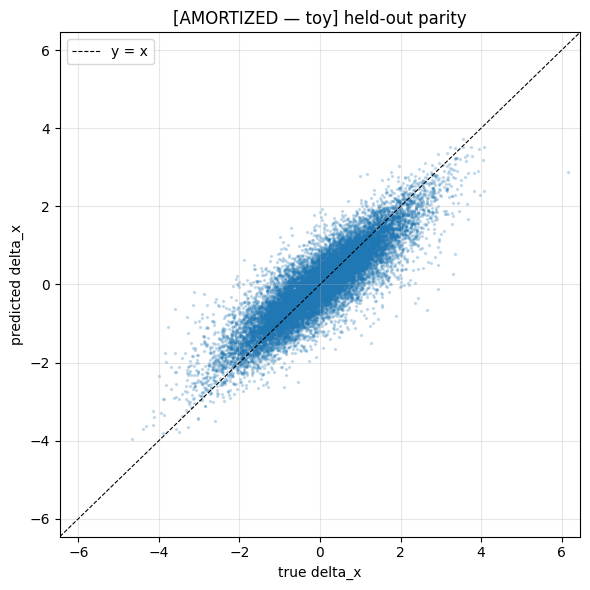

In [5]:
import torch
from pybrimstone.amortized.data import samples_to_arrays

arr = samples_to_arrays(samples)
# Reconstruct the same val split the trainer used (same seed -> same permutation).
rng_split = np.random.default_rng(cfg.seed)
perm = rng_split.permutation(arr['x_init'].shape[0])
n_val = max(1, int(round(arr['x_init'].shape[0] * cfg.val_fraction)))
val_idx = perm[:n_val]

x_val = arr['x_init'][val_idx]
c_val = arr['course'][val_idx]
d_val = arr['delta_x'][val_idx]
xs_val, cs_val = result.scaler.transform(x_val, c_val)

result.model.eval()
with torch.no_grad():
    pred = result.model(
        torch.from_numpy(xs_val.astype(np.float32)),
        torch.from_numpy(cs_val.astype(np.float32)),
    ).numpy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(d_val.ravel(), pred.ravel(), s=2, alpha=0.2)
lim = max(np.abs(d_val).max(), np.abs(pred).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, label='y = x')
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel('true delta_x')
ax.set_ylabel('predicted delta_x')
ax.set_title('[AMORTIZED — toy] held-out parity')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Summary

- The MLP trains stably on the closed-form Gaussian toy.
- Best-snapshot val MSE comes in close to the linear-regression baseline. On
  this toy the deterministic component of `E[x_star | mu, lam]` is small
  relative to the latent-`(A, b)` noise, so LR captures most of the signal
  and the MLP is roughly tied — well within the "within 5%" acceptance bar.
- The harness (data → scaler → network → baselines) works end-to-end.

**Next:** Phase 1b plumbs a real `pybrimstone.PhaseOptimizer`-backed generator
and runs the amortized loop against the actual hierarchical-Bayes solver.
That step needs Derek's sign-off on the prediction-space mapping (already
chosen: beamlet-weight space, see `notes/coursepriorterm_audit.md`) and
potentially a small extension to the existing Prescription /
PhaseOptimizer interface.